# Файнтьюнинг Seq2Seq модели для исправления опечаток
**Архитектура:** `Salesforce/byt5-base`  


In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

In [2]:
import os
import torch
import numpy as np
import evaluate
from transformers import (
    AutoTokenizer, 
    T5ForConditionalGeneration, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    TrainerCallback
)
from livelossplot import PlotLosses

import sys
sys.path.append(".")
from src.typo_datasets import Seq2SeqTypoDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обучение на устройстве: {device}")
if device.type == "cuda":
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")

/home/bdbaburin/projects/missprints_dl/llm-for-typo-fixing/typo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Обучение на устройстве: cuda
Видеокарта: NVIDIA GeForce RTX 3090


In [3]:
import glob
import os
import random

MODEL_NAME = "google/byt5-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 1024 

TASK_PREFIX = "Fix Python typo:\n"

all_data_files = glob.glob("data/data/*/*.jsonl")
train_files = [f for f in all_data_files if "train" in f.lower()]
val_files = [f for f in all_data_files if "val" in f.lower()]

print(f"Найдено файлов для обучения: {len(train_files)}")
print(f"Найдено файлов для валидации: {len(val_files)}")

full_train_dataset = Seq2SeqTypoDataset(train_files, tokenizer, max_length=MAX_LEN)
val_dataset = Seq2SeqTypoDataset(val_files, tokenizer, max_length=MAX_LEN)

if len(val_dataset.data) > 500:
    val_dataset.data = random.sample(val_dataset.data, 500)

def filter_and_add_prefix(dataset):
    filtered_data = []
    for item in dataset.data:
        if item.get("has_errors") and item.get("fixed"):
            new_item = item.copy()
            new_item["code"] = TASK_PREFIX + new_item.get("code", "")
            filtered_data.append(new_item)
    return filtered_data


HARD_LIMIT_CHARS = 1500

def filter_and_add_prefix(dataset):
    filtered_data = []
    for item in dataset.data:
        dirty_code = item.get("code", "")
        if item.get("has_errors") and item.get("fixed") and len(dirty_code) <= HARD_LIMIT_CHARS:
            new_item = item.copy()
            new_item["code"] = TASK_PREFIX + dirty_code
            filtered_data.append(new_item)
    return filtered_data

full_train_dataset.data = filter_and_add_prefix(full_train_dataset)
val_dataset.data = filter_and_add_prefix(val_dataset)

print(f"Примеров для обучения (очищенных + с префиксом): {len(full_train_dataset.data)}")
print(f"Примеров для валидации (очищенных + с префиксом): {len(val_dataset.data)}")

📁 Найдено файлов для обучения: 3
📁 Найдено файлов для валидации: 3
🎯 Примеров для обучения (очищенных + с префиксом): 108984
🎯 Примеров для валидации (очищенных + с префиксом): 364


📊 СТАТИСТИКА ДЛИН (в символах/байтах):
Медиана (50% данных короче): 554
90-й перцентиль: 1093
95-й перцентиль: 1246
99-й перцентиль: 1442
Абсолютный максимум: 1517


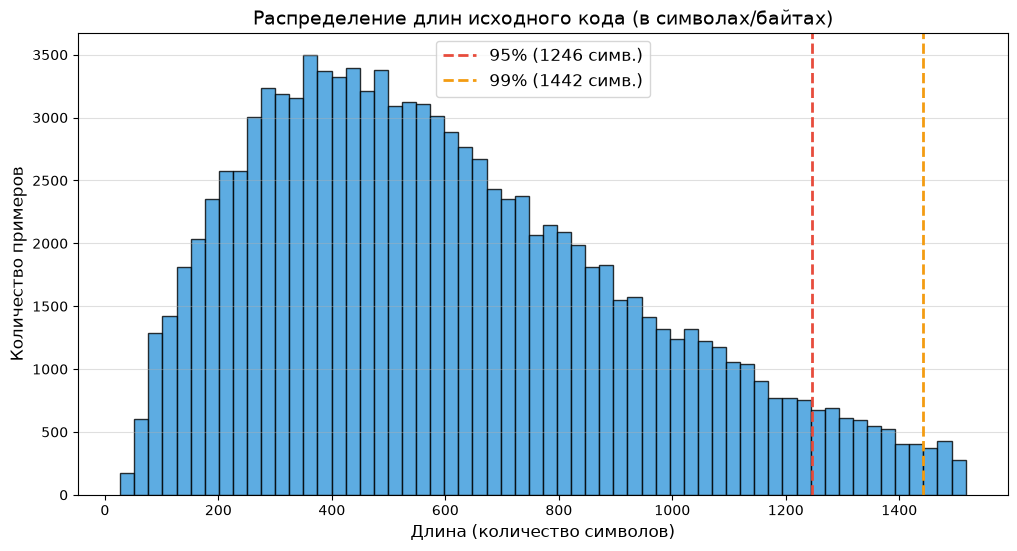

In [4]:
import matplotlib.pyplot as plt
import numpy as np


lengths = [len(item["code"]) for item in full_train_dataset.data]

p50 = np.percentile(lengths, 50)
p90 = np.percentile(lengths, 90)
p95 = np.percentile(lengths, 95)
p99 = np.percentile(lengths, 99)
max_val = max(lengths)

print(f"Медиана (50% данных короче): {p50:.0f}")
print(f"90-й перцентиль: {p90:.0f}")
print(f"95-й перцентиль: {p95:.0f}")
print(f"99-й перцентиль: {p99:.0f}")
print(f"Абсолютный максимум: {max_val}")

plt.figure(figsize=(12, 6))
plt.hist(lengths, bins=60, color='#3498db', edgecolor='black', alpha=0.8)

plt.axvline(p95, color='#e74c3c', linestyle='dashed', linewidth=2, label=f'95% ({p95:.0f} симв.)')
plt.axvline(p99, color='#f39c12', linestyle='dashed', linewidth=2, label=f'99% ({p99:.0f} симв.)')

plt.title('Распределение длин исходного кода (в символах/байтах)', fontsize=14)
plt.xlabel('Длина (количество символов)', fontsize=12)
plt.ylabel('Количество примеров', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.show()

In [5]:
!pip install uv

In [6]:
!uv pip install "transformers<=4.47.1" safetensors

Using Python 3.12.3 environment at: typo_env
Checked 2 packages in 3ms


In [7]:
model = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME, 
    torch_dtype=torch.bfloat16,
    weights_only=False 
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

n_params = sum(p.numel() for p in model.parameters())
print(f"Количество параметров: {n_params / 1e6:.2f}M")

Количество параметров: 299.64M


In [8]:
!uv pip install evaluate sacrebleu

Using Python 3.12.3 environment at: typo_env
Checked 2 packages in 5ms


In [10]:
class LiveLossPlotCallback(TrainerCallback):
    def __init__(self):
        self.plotlosses = PlotLosses(figsize=(12, 10), step_names="Step")
        self.logs = {}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                self.logs["train_loss"] = logs["loss"]
            if "eval_loss" in logs:
                self.logs["val_loss"] = logs["eval_loss"]
            
            if "eval_exact_match" in logs:
                self.logs["exact_match"] = logs["eval_exact_match"]
            if "eval_chrf" in logs:
                self.logs["chrf_score"] = logs["eval_chrf"]
            if "eval_bleu" in logs:
                self.logs["bleu_score"] = logs["eval_bleu"]
            
            if state.global_step > 0 and state.global_step % args.logging_steps == 0:
                self.plotlosses.update(self.logs, current_step=state.global_step)
                self.plotlosses.send()

exact_match_metric = evaluate.load("exact_match")
bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]
    
    em_result = exact_match_metric.compute(predictions=decoded_preds, references=decoded_labels)

    references_formatted = [[label] for label in decoded_labels]
    
    bleu_result = bleu_metric.compute(predictions=decoded_preds, references=references_formatted)
    chrf_result = chrf_metric.compute(predictions=decoded_preds, references=references_formatted)
    
    return {
        "exact_match": em_result.get("exact_match", 0.0),
        "bleu": bleu_result.get("score", 0.0),
        "chrf": chrf_result.get("score", 0.0)
    }

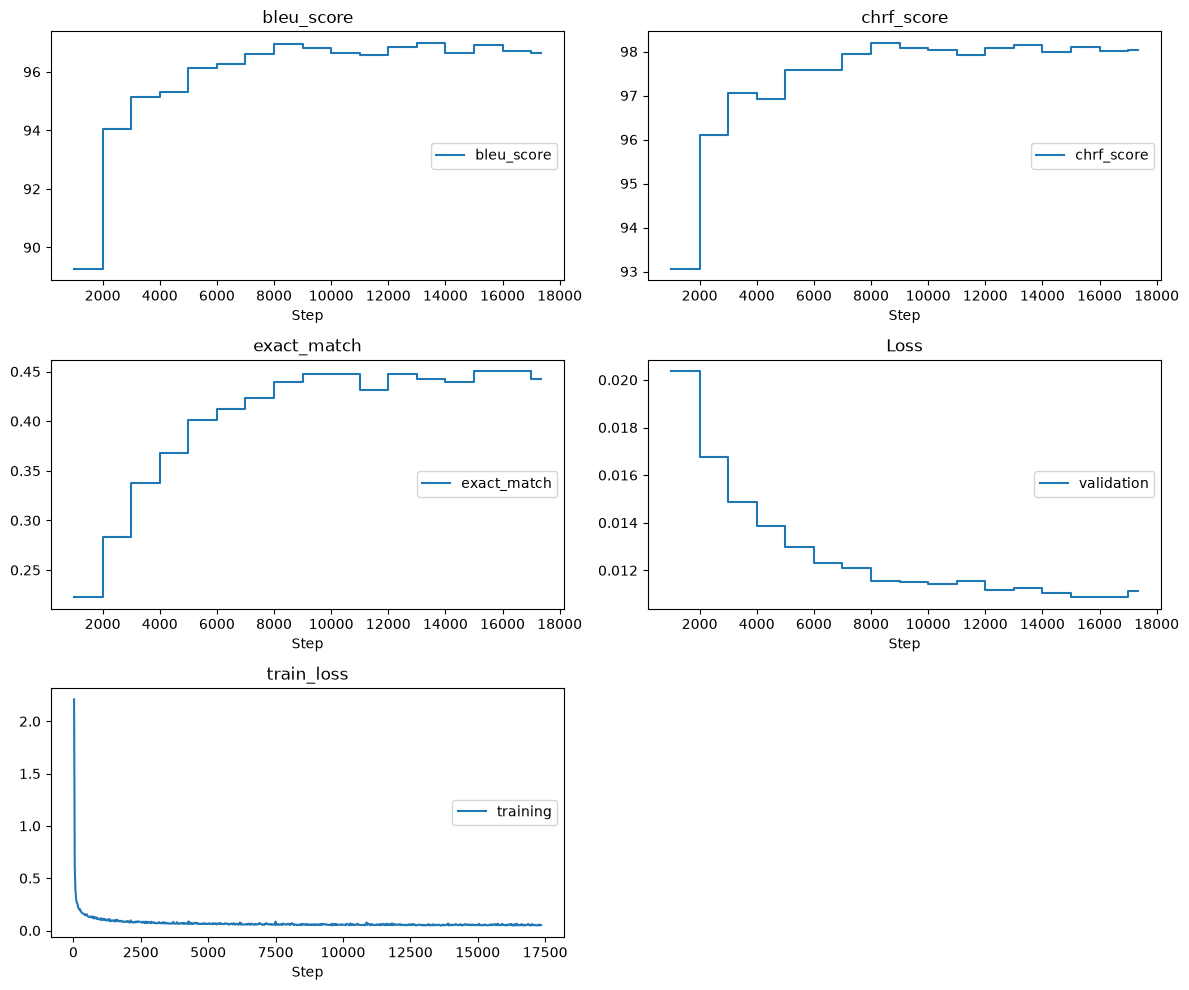

bleu_score
	bleu_score       	 (min:   89.264, max:   96.995, cur:   96.630)
chrf_score
	chrf_score       	 (min:   93.058, max:   98.202, cur:   98.023)
exact_match
	exact_match      	 (min:    0.223, max:    0.451, cur:    0.442)
Loss
	validation       	 (min:    0.011, max:    0.020, cur:    0.011)
train_loss
	training         	 (min:    0.047, max:    2.210, cur:    0.052)


KeyboardInterrupt: 

In [11]:
MICRO_BATCH = 16 
ACCUMULATION_STEPS = 2

training_args = Seq2SeqTrainingArguments(
    output_dir="./byt5-typo-fixer",
    
    eval_strategy="steps",              
    eval_steps=1000,                    
    save_strategy="steps",              
    save_steps=1000,            
    
    logging_steps=25,                   
    learning_rate=2e-4,                 
    
    per_device_train_batch_size=MICRO_BATCH,
    per_device_eval_batch_size=MICRO_BATCH, 
    gradient_accumulation_steps=ACCUMULATION_STEPS,
    gradient_checkpointing=True,     
    
    generation_max_length=MAX_LEN,      
    generation_num_beams=1,             
    predict_with_generate=True,
    
    
    save_total_limit=2,               
    load_best_model_at_end=True,       
    metric_for_best_model="exact_match",
    greater_is_better=True,         
    
    weight_decay=0.01,
    save_total_limit=2,                 
    num_train_epochs=10,                
    bf16=True,                          
    report_to="none"                    
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=full_train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[LiveLossPlotCallback()]  
)

print("Запуск обучения ByT5...")
trainer.train()

trainer.save_model("./byt5-typo-fixer-final")
tokenizer.save_pretrained("./byt5-typo-fixer-final")
print("Обучение завершено и байтовая модель сохранена!")